In [ ]:
import os
import shutil
from google.colab import drive

# 1. CÀI ĐẶT THƯ VIỆN CẦN THIẾT
!pip install editdistance
!apt-get install unrar > /dev/null

# 2. MOUNT DRIVE (Để lưu model)
if not os.path.exists('/content/drive'):
    drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import os
import shutil
from google.colab import drive

# 1. CÀI ĐẶT THƯ VIỆN CẦN THIẾT
!pip install editdistance
!apt-get install unrar > /dev/null

# 2. MOUNT DRIVE (Để lưu model)
if not os.path.exists('/content/drive'):
    drive.mount('/content/drive')

CKPT_SAVE_PATH = "/content/drive/MyDrive/crnn_best.pth"
print(f"--> Checkpoint sẽ được lưu tại: {CKPT_SAVE_PATH}")

# 3. GIẢI NÉN DỮ LIỆU (Train/Valid/Test)
# Cấu hình tên file đã upload
rar_files = {
    "train": "train.rar",
    "valid": "valid.rar",
    "test":  "test.rar"
}

for mode, filename in rar_files.items():
    rar_path = f"/content/{filename}"
    extract_to = f"/content/{mode}" # /content/train

    if os.path.exists(rar_path):
        if not os.path.exists(extract_to):
            os.makedirs(extract_to)
        print(f"Đang giải nén {filename} vào {extract_to}...")

        # Lệnh giải nén (x: extract, -inul: im lặng, -o+: ghi đè)
        # Thêm dấu "" quanh đường dẫn để tránh lỗi nếu tên file có khoảng trắng
        !unrar x -inul -o+ "{rar_path}" "{extract_to}"

        # --- ĐOẠN CODE ĐẾM FILE ---
        total_files = 0
        for root, dirs, files in os.walk(extract_to):
            total_files += len(files)
        # --------------------------

        print(f"--> Xong {mode}! Tổng số file đã giải nén: {total_files}")
    else:
        print(f"[Cảnh báo] Không tìm thấy file {filename}. Hãy upload lên Colab!")

^C
--> Checkpoint sẽ được lưu tại: /content/drive/MyDrive/ocr_transformer_best.pth
Đang giải nén train.rar vào /content/train...
--> Xong train! Tổng số file đã giải nén: 330961
Đang giải nén valid.rar vào /content/valid...
--> Xong valid! Tổng số file đã giải nén: 41370
Đang giải nén test.rar vào /content/test...
--> Xong test! Tổng số file đã giải nén: 41370


In [ ]:
import pandas as pd

# Tên file CSV gốc bạn upload
csv_files = {
    "train": "written_name_train.csv",
    "valid": "written_name_valid.csv",
    "test":  "written_name_test.csv"
}

# 1. TẠO DATASET TRAIN RÚT GỌN (120k mẫu)
if os.path.exists(csv_files["train"]):
    print("Đang xử lý Train CSV...")
    df = pd.read_csv(csv_files["train"])
    # Lấy 120k mẫu ngẫu nhiên
    SAMPLE_SIZE = 120000
    if len(df) > SAMPLE_SIZE:
        df = df.sample(n=SAMPLE_SIZE, random_state=42).reset_index(drop=True)
    df.to_csv("train_mini.csv", index=False)
    print(f"--> Đã tạo 'train_mini.csv' ({len(df)} dòng)")

# 2. TẠO DATASET VALID RÚT GỌN (5k mẫu)
if os.path.exists(csv_files["valid"]):
    print("Đang xử lý Valid CSV...")
    df = pd.read_csv(csv_files["valid"])
    VALID_SIZE = 5000
    if len(df) > VALID_SIZE:
        df = df.sample(n=VALID_SIZE, random_state=42).reset_index(drop=True)
    df.to_csv("valid_mini.csv", index=False)
    print(f"--> Đã tạo 'valid_mini.csv' ({len(df)} dòng)")

# 3. XỬ LÝ DATASET TEST (LỌC RÁC)
if os.path.exists(csv_files["test"]):
    print("Đang xử lý Test CSV...")
    df = pd.read_csv(csv_files["test"])
    # Lọc bỏ UNREADABLE và NaN
    df = df[df['IDENTITY'] != 'UNREADABLE']
    df = df.dropna(subset=['IDENTITY', 'FILENAME'])
    # Sửa tên file: bỏ đường dẫn thừa nếu có (VD: test/img.jpg -> img.jpg)
    df['FILENAME'] = df['FILENAME'].apply(lambda x: os.path.basename(x))

    df.to_csv("test_clean.csv", index=False)
    print(f"--> Đã tạo 'test_clean.csv' ({len(df)} dòng sạch)")

Đang xử lý Train CSV...
--> Đã tạo 'train_mini.csv' (120000 dòng)
Đang xử lý Valid CSV...
--> Đã tạo 'valid_mini.csv' (5000 dòng)
Đang xử lý Test CSV...
--> Đã tạo 'test_clean.csv' (41289 dòng sạch)


In [ ]:
import cv2
import numpy as np
import torch
import glob
import pandas as pd
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from tqdm.auto import tqdm
import os

# --- CONFIG (Đã sửa cho CRNN) ---
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
IMG_H = 32
IMG_W = 128
BATCH_SIZE = 64
EPOCHS = 30
LR = 5e-4
MAX_LEN = 32

CHARS = "ABCDEFGHIJKLMNOPQRSTUVWXYZ0123456789: "
# CTC Loss quy định:
# Index 0 thường dùng làm BLANK token (ký tự rỗng)
# Các ký tự thực sẽ bắt đầu từ 1
BLANK_IDX = 0
char2idx = {c: i + 1 for i, c in enumerate(CHARS)}
idx2char = {i + 1: c for i, c in enumerate(CHARS)}

# Số lớp = Số ký tự + 1 (Blank)
NUM_CLASSES = len(CHARS) + 1

# --- HÀM TỰ ĐỘNG TÌM ẢNH ---
def find_image_folder(base_path):
    if not os.path.exists(base_path): return base_path
    print(f"Đang quét tìm ảnh trong: {base_path} ...")
    for root, dirs, files in os.walk(base_path):
        if any(f.lower().endswith(('.jpg', '.png')) for f in files):
            count = sum(1 for f in files if f.lower().endswith(('.jpg', '.png')))
            if count > 10:
                print(f"--> TÌM THẤY ẢNH TẠI: {root} (SL: {count})")
                return root
    return base_path

class OCRDataset(Dataset):
    def __init__(self, csv_file, img_dir, mode='train'):
        self.df = pd.read_csv(csv_file)
        self.img_dir = img_dir
        self.mode = mode

        # Transform
        if mode == 'train':
            self.tf = transforms.Compose([
                transforms.ToPILImage(),
                transforms.RandomAffine(degrees=5, translate=(0.05, 0.05), scale=(0.9, 1.1)),
                transforms.ToTensor(),
                transforms.Normalize((0.5,), (0.5,))
            ])
        else:
            self.tf = transforms.Compose([
                transforms.ToPILImage(),
                transforms.ToTensor(),
                transforms.Normalize((0.5,), (0.5,))
            ])

    def encode(self, text):
        text = str(text).upper()
        seq = []
        for c in text:
            if c in char2idx:
                seq.append(char2idx[c])
        # Với CTC, ta không cần thêm SOS hay EOS, chỉ cần chuỗi index ký tự
        return torch.tensor(seq, dtype=torch.long)

    def crop_to_content(self, img):
        img_inv = 255 - img
        coords = cv2.findNonZero(img_inv)
        if coords is not None:
            x, y, w, h = cv2.boundingRect(coords)
            crop = img[y:y+h, x:x+w]
            if crop.shape[0] > 5 and crop.shape[1] > 5:
                return crop
        return img

    def resize_with_padding(self, img, target_h=32, target_w=128):
        h, w = img.shape
        scale = min(target_h / h, target_w / w)
        new_w = int(w * scale); new_h = int(h * scale)
        img_resized = cv2.resize(img, (new_w, new_h))
        padded = np.full((target_h, target_w), 255, dtype=np.uint8)
        padded[:new_h, :new_w] = img_resized
        return padded

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        img_path = os.path.join(self.img_dir, row["FILENAME"])

        # Đọc ảnh grayscale
        img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)
        if img is None: img = np.zeros((IMG_H, IMG_W), dtype=np.uint8)

        try:
            _, img = cv2.threshold(img, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)
        except: pass

        img = self.crop_to_content(img)
        img = self.resize_with_padding(img, IMG_H, IMG_W)
        img = self.tf(img)

        label = self.encode(row["IDENTITY"])
        return img, label

    def __len__(self): return len(self.df)

def collate_fn(batch):
    imgs, labels = zip(*batch)
    imgs = torch.stack(imgs)

    # Pad labels bằng BLANK_IDX (0) để tạo thành tensor chữ nhật
    # CTC Loss trong PyTorch hỗ trợ xử lý padding nếu ta cung cấp length chính xác
    lengths = torch.tensor([len(l) for l in labels], dtype=torch.long)
    max_len = max(lengths)
    padded_labels = torch.full((len(labels), max_len), BLANK_IDX, dtype=torch.long)

    for i, l in enumerate(labels):
        padded_labels[i, :len(l)] = l

    return imgs, padded_labels, lengths

# --- KHỞI TẠO DATALOADER ---
print("\n--- CHECK ĐƯỜNG DẪN ẢNH ---")
real_train_dir = find_image_folder("/content/train")
real_valid_dir = find_image_folder("/content/valid")

if os.path.exists("train_mini.csv"):
    train_ds = OCRDataset("train_mini.csv", real_train_dir, mode='train')
    train_loader = DataLoader(train_ds, BATCH_SIZE, shuffle=True, collate_fn=collate_fn, num_workers=2, pin_memory=True)
    print(f"Ready Train: {len(train_ds)}")

if os.path.exists("valid_mini.csv"):
    valid_ds = OCRDataset("valid_mini.csv", real_valid_dir, mode='valid')
    valid_loader = DataLoader(valid_ds, BATCH_SIZE, shuffle=False, collate_fn=collate_fn, num_workers=2, pin_memory=True)
    print(f"Ready Valid: {len(valid_ds)}")


--- CHECK ĐƯỜNG DẪN ẢNH ---
Đang quét tìm ảnh trong: /content/train ...
--> TÌM THẤY ẢNH TẠI: /content/train/train/train (SL: 330961)
Đang quét tìm ảnh trong: /content/valid ...
--> TÌM THẤY ẢNH TẠI: /content/valid/valid/valid (SL: 41370)
Ready Train: 120000
Ready Valid: 5000


In [ ]:
from torch import nn

class CNNEncoder(nn.Module):
    def __init__(self):
        super().__init__()
        # Giữ nguyên kiến trúc CNN cũ của bạn vì nó giảm kích thước xuống (H/16, W/4)
        # Input: (1, 32, 128) -> Output CNN: (512, 2, 32)
        # Permute/View trong forward sẽ đổi thành (B, 32, 1024)
        self.cnn = nn.Sequential(
            nn.Conv2d(1, 64, 3, 1, 1), nn.BatchNorm2d(64), nn.ReLU(), nn.MaxPool2d(2, 2),
            nn.Conv2d(64, 128, 3, 1, 1), nn.BatchNorm2d(128), nn.ReLU(), nn.MaxPool2d(2, 2),
            nn.Conv2d(128, 256, 3, 1, 1), nn.BatchNorm2d(256), nn.ReLU(), nn.MaxPool2d((2, 1)),
            nn.Conv2d(256, 512, 3, 1, 1), nn.BatchNorm2d(512), nn.ReLU(), nn.MaxPool2d((2, 1)),
        )
    def forward(self, x):
        # x: (B, 1, 32, 128)
        x = self.cnn(x)
        # Output shape: (B, 512, 2, 32) (Channels, H, W)

        # Để đưa vào RNN, ta cần shape (B, Time, Features)
        # Coi chiều rộng W (32) là Time.
        # Gom chiều cao H (2) và Channels (512) thành Features (1024).
        b, c, h, w = x.shape
        x = x.permute(0, 3, 1, 2).contiguous() # (B, W, C, H) -> (B, 32, 512, 2)
        x = x.view(b, w, c * h)                # (B, 32, 1024)
        return x

class CRNN(nn.Module):
    def __init__(self, num_classes, hidden_size=256):
        super().__init__()
        self.encoder = CNNEncoder()

        # Bi-LSTM để học chuỗi
        self.rnn = nn.LSTM(input_size=1024,
                           hidden_size=hidden_size,
                           num_layers=2,
                           batch_first=True,
                           bidirectional=True,
                           dropout=0.2)

        # Output layer
        self.fc = nn.Linear(hidden_size * 2, num_classes)

    def forward(self, x):
        # 1. CNN Features
        features = self.encoder(x) # (B, 32, 1024)

        # 2. RNN Sequence Modeling
        rnn_out, _ = self.rnn(features) # (B, 32, 512)

        # 3. Class Prediction
        out = self.fc(rnn_out) # (B, 32, num_classes)

        return out

model = CRNN(num_classes=NUM_CLASSES).to(DEVICE)
print(f"Mô hình CRNN đã khởi tạo với {NUM_CLASSES} classes (bao gồm Blank).")

Mô hình CRNN đã khởi tạo với 39 classes (bao gồm Blank).


In [ ]:
import torch.optim as optim

# CTC Loss: input (T, N, C), target (N, S)
criterion = nn.CTCLoss(blank=BLANK_IDX, zero_infinity=True)
optimizer = optim.Adam(model.parameters(), lr=LR)

def train_one_epoch(model, dataloader, optimizer, criterion):
    model.train()
    total_loss = 0

    # Batch trả về: imgs, padded_labels, lengths
    for imgs, targets, target_lengths in tqdm(dataloader, desc="Training"):
        imgs = imgs.to(DEVICE)
        targets = targets.to(DEVICE)
        target_lengths = target_lengths.to(DEVICE)

        optimizer.zero_grad()

        # Forward
        preds = model(imgs) # (B, 32, C)

        # Chuẩn bị cho CTC Loss:
        # 1. Log Softmax
        # 2. Permute thành (Time, Batch, Class)
        log_probs = torch.nn.functional.log_softmax(preds, dim=2).permute(1, 0, 2)

        # 3. Input Lengths: Luôn là 32 (chiều rộng sau CNN)
        batch_size = imgs.size(0)
        input_lengths = torch.full((batch_size,), 32, dtype=torch.long).to(DEVICE)

        # Tính Loss
        loss = criterion(log_probs, targets, input_lengths, target_lengths)

        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 5.0) # Tránh bùng nổ gradient
        optimizer.step()

        total_loss += loss.item()

    return total_loss / len(dataloader)

@torch.no_grad()
def evaluate(model, dataloader, criterion):
    model.eval()
    total_loss = 0
    for imgs, targets, target_lengths in dataloader:
        imgs = imgs.to(DEVICE)
        targets = targets.to(DEVICE)
        target_lengths = target_lengths.to(DEVICE)

        preds = model(imgs)
        log_probs = torch.nn.functional.log_softmax(preds, dim=2).permute(1, 0, 2)
        input_lengths = torch.full((imgs.size(0,),), 32, dtype=torch.long).to(DEVICE)

        loss = criterion(log_probs, targets, input_lengths, target_lengths)
        total_loss += loss.item()

    return total_loss / len(dataloader)

# --- START TRAINING ---
best_val_loss = float('inf')
history = {'train_loss': [], 'val_loss': []}

for epoch in range(EPOCHS):
    train_loss = train_one_epoch(model, train_loader, optimizer, criterion)
    val_loss = evaluate(model, valid_loader, criterion)

    history['train_loss'].append(train_loss)
    history['val_loss'].append(val_loss)

    print(f"Epoch {epoch+1}/{EPOCHS} | Train Loss: {train_loss:.4f} | Val Loss: {val_loss:.4f}")

    if val_loss < best_val_loss:
        best_val_loss = val_loss
        torch.save(model.state_dict(), "crnn_best.pth")
        print("--> Saved Best Model!")

Training:   0%|          | 0/1875 [00:00<?, ?it/s]

Exception ignored in: <function _MultiProcessingDataLoaderIter.__del__ at 0x7a316edbf4c0>
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1654, in __del__
    self._shutdown_workers()
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1637, in _shutdown_workers
    if w.is_alive():
       ^^^^^^^^^^^^
  File "/usr/lib/python3.12/multiprocessing/process.py", line 160, in is_alive
    assert self._parent_pid == os.getpid(), 'can only test a child process'
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
AssertionError: can only test a child process
Exception ignored in: <function _MultiProcessingDataLoaderIter.__del__ at 0x7a316edbf4c0>
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1654, in __del__
    self._shutdown_workers()
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 16

Epoch 1/30 | Train Loss: 1.1067 | Val Loss: 0.5308
--> Saved Best Model!


Training:   0%|          | 0/1875 [00:00<?, ?it/s]

Exception ignored in: <function _MultiProcessingDataLoaderIter.__del__ at 0x7a316edbf4c0>
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1654, in __del__
    self._shutdown_workers()
Exception ignored in:   File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1637, in _shutdown_workers
<function _MultiProcessingDataLoaderIter.__del__ at 0x7a316edbf4c0>
    Traceback (most recent call last):
if w.is_alive():  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1654, in __del__

     self._shutdown_workers() 
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1637, in _shutdown_workers
      if w.is_alive():  
 ^  ^ ^^ ^ ^ ^ ^^^^^^^^
^  File "/usr/lib/python3.12/multiprocessing/process.py", line 160, in is_alive
^    ^^assert self._parent_pid == os.getpid(), 'can only test a child process'^
 ^^ ^ ^ 
    File "/usr/lib/

...

Exception ignored in: <function _MultiProcessingDataLoaderIter.__del__ at 0x7a316edbf4c0>
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1654, in __del__
    self._shutdown_workers()
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1637, in _shutdown_workers
    if w.is_alive():
       ^^^^^^^^^^^^
  File "/usr/lib/python3.12/multiprocessing/process.py", line 160, in is_alive
    assert self._parent_pid == os.getpid(), 'can only test a child process'
     Exception ignored in:  <function _MultiProcessingDataLoaderIter.__del__ at 0x7a316edbf4c0> 
Traceback (most recent call last):
   File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1654, in __del__
      self._shutdown_workers() 
^  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1637, in _shutdown_workers
^    ^if w.is_alive():^^
^  ^ ^ ^^^  ^ ^^^^^^^^^^^^^

Epoch 29/30 | Train Loss: 0.2563 | Val Loss: 0.2704


Training:   0%|          | 0/1875 [00:00<?, ?it/s]

Exception ignored in: <function _MultiProcessingDataLoaderIter.__del__ at 0x7a316edbf4c0>
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1654, in __del__
    self._shutdown_workers()
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1637, in _shutdown_workers
    if w.is_alive():
       ^^^^^^^^^^^^
  File "/usr/lib/python3.12/multiprocessing/process.py", line 160, in is_alive
    assert self._parent_pid == os.getpid(), 'can only test a child process'
           ^^^^^^^^^^^^^^^^^^^^^^Exception ignored in: ^<function _MultiProcessingDataLoaderIter.__del__ at 0x7a316edbf4c0>^
^Traceback (most recent call last):
^^  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1654, in __del__
^    ^self._shutdown_workers()
^^  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1637, in _shutdown_workers

    AssertionErrorif 

Epoch 30/30 | Train Loss: 0.2509 | Val Loss: 0.2768


Đang quét tìm ảnh trong: /content/test ...
--> TÌM THẤY ẢNH TẠI: /content/test/test/test (SL: 41370)
>>> ĐANG ĐÁNH GIÁ TRÊN TẬP TEST...


  0%|          | 0/646 [00:00<?, ?it/s]

Exception ignored in: <function _MultiProcessingDataLoaderIter.__del__ at 0x7a316edbf4c0>
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1654, in __del__
    self._shutdown_workers()
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1637, in _shutdown_workers
    if w.is_alive():
       ^^^^^^^^^^^^
  File "/usr/lib/python3.12/multiprocessing/process.py", line 160, in is_alive
    assert self._parent_pid == os.getpid(), 'can only test a child process'
           ^^^^^^^^^^Exception ignored in: ^<function _MultiProcessingDataLoaderIter.__del__ at 0x7a316edbf4c0>^
^Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1654, in __del__
^    ^self._shutdown_workers()^
^  File "/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py", line 1637, in _shutdown_workers
^^    ^if w.is_alive():^
^ ^^ ^ ^ ^ 


ACCURACY: 76.97%
CER: 0.0650


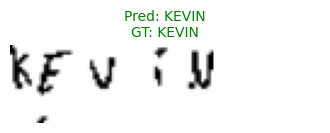

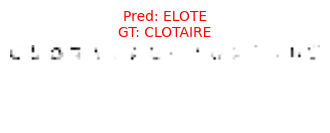

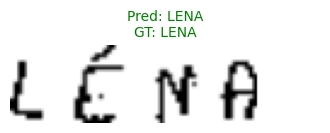

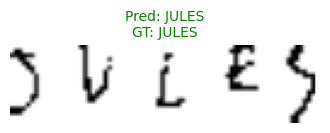

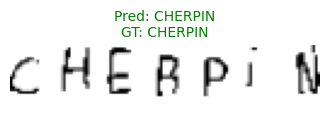

In [ ]:
import editdistance
import matplotlib.pyplot as plt

# Load lại best model
if os.path.exists("crnn_best.pth"):
    model.load_state_dict(torch.load("crnn_best.pth", map_location=DEVICE))
model.eval()

# Tìm folder test
real_test_dir = find_image_folder("/content/test")
if os.path.exists("test_clean.csv"):
    test_ds = OCRDataset("test_clean.csv", real_test_dir, mode='test')
    test_loader = DataLoader(test_ds, BATCH_SIZE, shuffle=False, collate_fn=collate_fn, num_workers=2)

def ctc_decode(log_probs, idx2char):
    # log_probs: (Time, Batch, Class) -> Lấy argmax -> (Time, Batch)
    # Tuy nhiên model output gốc là (Batch, Time, Class), ta lấy argmax trực tiếp
    preds = log_probs.argmax(dim=2).detach().cpu().numpy() # (B, 32)
    decoded_texts = []
    for p in preds:
        res = []
        prev_char = -1
        for char_idx in p:
            # Logic CTC: Bỏ qua BLANK và ký tự lặp lại liên tiếp
            if char_idx != BLANK_IDX and char_idx != prev_char:
                res.append(idx2char[char_idx])
            prev_char = char_idx
        decoded_texts.append("".join(res))
    return decoded_texts

# Đánh giá
correct = 0; total = 0; total_cer = 0
viz_samples = []

print(">>> ĐANG ĐÁNH GIÁ TRÊN TẬP TEST...")
with torch.no_grad():
    for imgs, targets, target_lengths in tqdm(test_loader):
        imgs = imgs.to(DEVICE)

        # Forward
        preds = model(imgs) # (B, 32, C)

        # Decode
        pred_texts = ctc_decode(preds, idx2char)

        # Decode Ground Truth (Nhãn thật)
        # targets là tensor (B, MaxLen) đã padding
        target_texts = []
        for i, t in enumerate(targets):
            length = target_lengths[i]
            # Lấy đúng độ dài, bỏ padding
            real_indices = t[:length].tolist()
            text = "".join([idx2char[idx] for idx in real_indices])
            target_texts.append(text)

        # So sánh
        for i in range(len(pred_texts)):
            p = pred_texts[i]
            g = target_texts[i]

            if p == g: correct += 1
            if len(g) > 0:
                total_cer += editdistance.eval(p, g) / len(g)
            total += 1

            if len(viz_samples) < 5:
                viz_samples.append((imgs[i], p, g))

print(f"\nACCURACY: {correct/total:.2%}")
print(f"CER: {total_cer/total:.4f}")

# Vẽ 5 ảnh mẫu
for img, p, g in viz_samples:
    img_np = img.permute(1, 2, 0).cpu().numpy() * 0.5 + 0.5
    plt.figure(figsize=(4, 1.5))
    plt.imshow(img_np.squeeze(), cmap='gray', vmin=0, vmax=1)
    plt.title(f"Pred: {p}\nGT: {g}", color='green' if p==g else 'red', fontsize=10)
    plt.axis('off')
    plt.show()